In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import scipy.stats as stats
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

Преобразование данных

In [6]:
df = pd.read_csv('stocks.csv', parse_dates=['Date'], dayfirst=True)
df = df.drop_duplicates(subset=['Date', 'Ticker'])
aapl = df[df['Ticker'] == 'AAPL'].copy().sort_values('Date').dropna(subset=['Adj_Close']).reset_index(drop=True)

returns = np.log(aapl['Adj_Close'] / aapl['Adj_Close'].shift(1)).dropna().values

In [7]:
look_back = 20
X, y = [], []
for i in range(len(returns) - look_back):
    X.append(returns[i:i+look_back])
    y.append(returns[i+look_back])

X = np.array(X).reshape((-1, look_back, 1))
y = np.array(y)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

Зафиксируем seed для воспроизводимости

In [8]:
np.random.seed(42)
torch.manual_seed(42)

Преобразуем данные в тензоры

In [9]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

Создадим DataLoader для тренировки

In [10]:
batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

Определим модель LSTM

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape - (batch, seq_len, input_size)
        out, _ = self.lstm(x)          # out shape - (batch, seq_len, hidden_size)
        out = self.dropout(out[:, -1, :])
        out = self.linear(out)
        return out

model = LSTMModel(input_size=1, hidden_size=50, num_layers=1, dropout=0.2)
print(model)

LSTMModel(
  (lstm): LSTM(1, 50, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)


/opt/homebrew/lib/python3.14/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Зафиксируем параметры обучения

In [12]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100
train_losses = []
val_losses = []

Для валидации будем использовать последнии 10% train выборки

In [13]:
val_size = int(0.1 * len(X_train_t))
X_val_t = X_train_t[-val_size:]
y_val_t = y_train_t[-val_size:]
X_train_trunc = X_train_t[:-val_size]
y_train_trunc = y_train_t[:-val_size]

train_dataset = TensorDataset(X_train_trunc, y_train_trunc)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

Обучим модель

In [14]:
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
    train_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()
        val_losses.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(f'epoch {epoch + 1}/{epochs} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}')

epoch 10/100 | train loss: 0.000346 | val loss: 0.000421
epoch 20/100 | train loss: 0.000322 | val loss: 0.000422
epoch 30/100 | train loss: 0.000323 | val loss: 0.000440
epoch 40/100 | train loss: 0.000318 | val loss: 0.000422
epoch 50/100 | train loss: 0.000317 | val loss: 0.000424
epoch 60/100 | train loss: 0.000318 | val loss: 0.000430
epoch 70/100 | train loss: 0.000316 | val loss: 0.000426
epoch 80/100 | train loss: 0.000315 | val loss: 0.000421
epoch 90/100 | train loss: 0.000316 | val loss: 0.000424
epoch 100/100 | train loss: 0.000316 | val loss: 0.000423


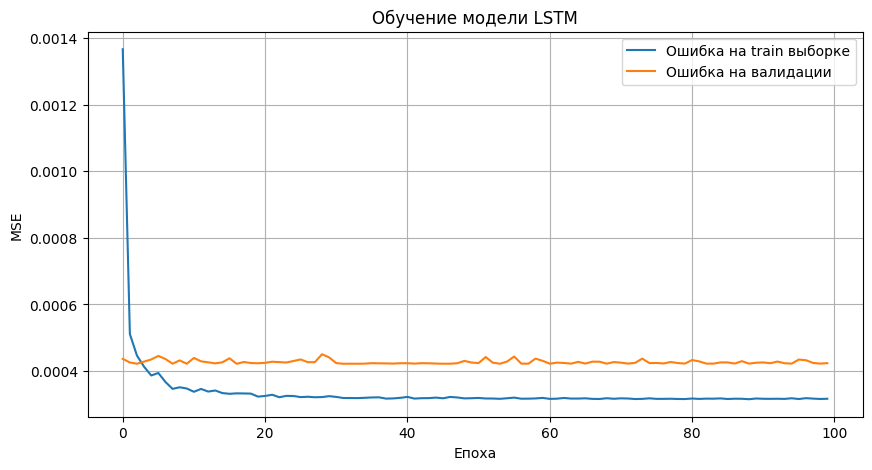

In [21]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Ошибка на train выборке')
plt.plot(val_losses, label='Ошибка на валидации')
plt.xlabel('Епоха')
plt.ylabel('MSE')
plt.title('Обучение модели LSTM')
plt.legend()
plt.grid(True)
plt.show()

Сделаем прогноз на test выборке

In [18]:
model.eval()
with torch.no_grad():
    y_pred_t = model(X_test_t)
    y_pred = y_pred_t.numpy().flatten()
    y_test_np = y_test_t.numpy().flatten()

residuals = y_test_np - y_pred

rmse = np.sqrt(mean_squared_error(y_test_np, y_pred))
mae = mean_absolute_error(y_test_np, y_pred)
print(f'RMSE: {rmse:.6f}')
print(f'MAE: {mae:.6f}')

RMSE: 0.016365
MAE: 0.011221


Проанализируем распределение остатков

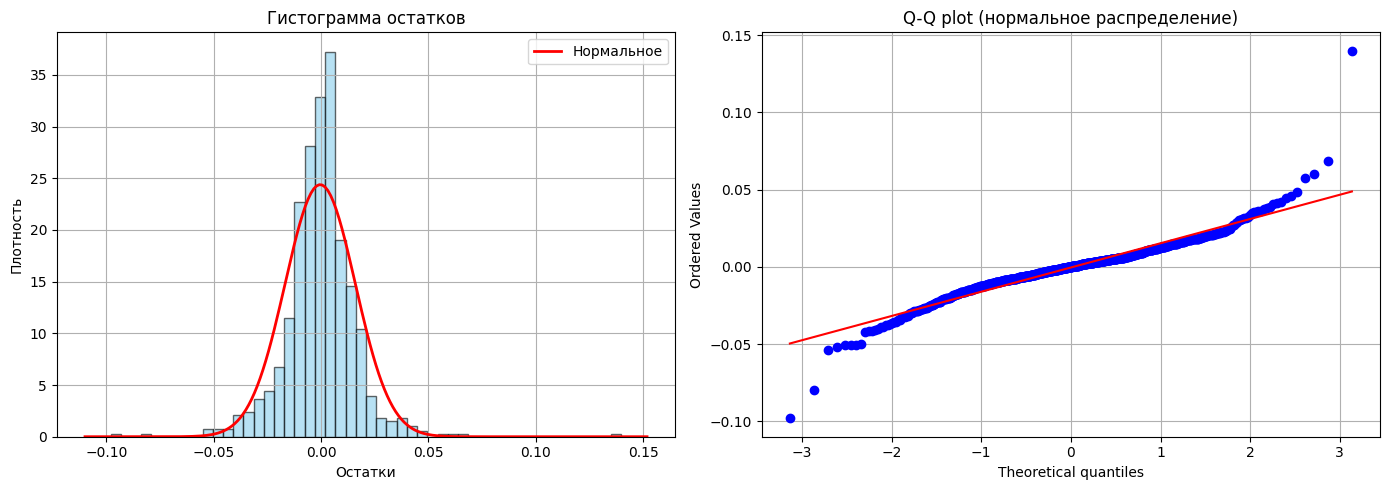

In [23]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.hist(residuals, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
mu, std = np.mean(residuals), np.std(residuals)
plt.plot(x, stats.norm.pdf(x, mu, std), 'r-', lw=2, label='Нормальное')
plt.xlabel('Остатки')
plt.ylabel('Плотность')
plt.title('Гистограмма остатков')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q plot (нормальное распределение)')
plt.grid(True)

plt.tight_layout()
plt.show()

Параметры t-распределения: df=3.22, loc=-0.000110, scale=0.010536


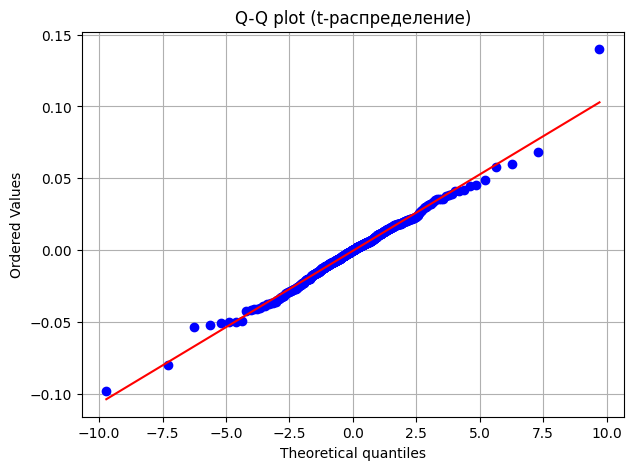

In [24]:
t_params = stats.t.fit(residuals)
print(f"Параметры t-распределения: df={t_params[0]:.2f}, loc={t_params[1]:.6f}, scale={t_params[2]:.6f}")

plt.figure(figsize=(7,5))
stats.probplot(residuals, dist=stats.t, sparams=(t_params[0],), plot=plt)
plt.title('Q-Q plot (t-распределение)')
plt.grid(True)
plt.show()